In [2]:
import pandas as pd
import seaborn as sns
import numpy as np

In [3]:
queries_path = "/data2/knn_datasets/sparse_datasets/msmarco_v1_passage/cocondenser/data/queries.bin"
doc_path = "/data2/knn_datasets/sparse_datasets/msmarco_v1_passage/cocondenser/data/documents.bin"

In [5]:
import struct
from tqdm import tqdm

def read_sparse_vectors_from_binary_file(filename):
    """
    Reads a binary file in the format produced by write_sparse_vectors_to_binary_file:
      [N_terms  : uint32]
      For each of N_terms:
        [L       : uint32]
        [idx_1..idx_L : L × uint32]
        [val_1..val_L : L × float32]
    Returns a list of dicts mapping each idx_i to val_i.
    """
    vectors = []
    with open(filename, "rb") as fin:
        # Read number of term‐dicts
        raw = fin.read(4)
        if len(raw) < 4:
            raise EOFError("Unexpected end of file when reading number of vectors")
        n_terms, = struct.unpack("<I", raw)

        for _ in tqdm(range(n_terms), desc="Reading term vectors"):
            # Read vector length L
            raw = fin.read(4)
            if len(raw) < 4:
                raise EOFError("Unexpected end of file when reading vector length")
            L, = struct.unpack("<I", raw)

            # Read L indices (uint32)
            idx_bytes = fin.read(4 * L)
            if len(idx_bytes) < 4 * L:
                raise EOFError("Unexpected end of file when reading indices")
            indices = struct.unpack(f"<{L}I", idx_bytes)

            # Read L float32 values
            val_bytes = fin.read(4 * L)
            if len(val_bytes) < 4 * L:
                raise EOFError("Unexpected end of file when reading values")
            values = struct.unpack(f"<{L}f", val_bytes)

            # Build dict and append
            vectors.append({idx: val for idx, val in zip(indices, values)})

    return vectors

In [6]:
queries = read_sparse_vectors_from_binary_file(queries_path)

Reading term vectors: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6980/6980 [00:00<00:00, 125814.34it/s]


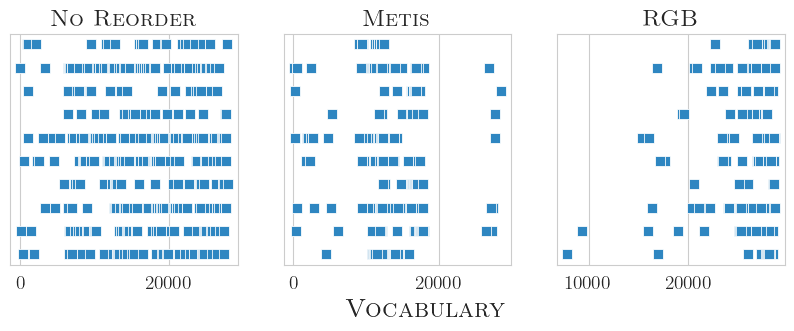

In [13]:
import matplotlib.pyplot as plt

n_queries = 10
queries_ids = np.random.choice(len(queries), n_queries)

sns.set_style("whitegrid")
# Enable TeX rendering and configure font sizes
plt.rc('text', usetex=True)
plt.rc('font', family='serif')  # use LaTeX serif font
MEDIUM_SIZE = 19
BIGGER_SIZE = 25

plt.rc('font', size=MEDIUM_SIZE)
plt.rc('axes', titlesize=MEDIUM_SIZE - 2)
plt.rc('axes', labelsize=MEDIUM_SIZE - 2)
plt.rc('xtick', labelsize=MEDIUM_SIZE - 5)
plt.rc('ytick', labelsize=MEDIUM_SIZE)
plt.rc('legend', fontsize=MEDIUM_SIZE - 2)
plt.rc('figure', titlesize=MEDIUM_SIZE)

sns.set_style("whitegrid")

n_cols = 3
fig, (ax1, ax2, ax3) = plt.subplots(1, n_cols, sharey=True, figsize=(10, 3))

ax1.set_yticks(np.arange(n_queries))
ax1.set_title(r"\textsc{No Reorder}")
#ax1.set_yticklabels([f"Q{i+1}" for i in np.arange(n_queries)])

ax2.set_yticks([])
ax2.set_title(r"\textsc{Metis}")


ax3.set_yticks([])
ax3.set_title(r"\textsc{RGB}")



colors = ["#2E86C1", "#28B463", "#F39C12", "#D35400", "#8E44AD"]
sns.set_palette(colors)


metis_permutation_path = "/home/cosimorulli/next_develop_seismic/seismic_private/_metis_8edf21a894a9745b.txt"
metis_permutation = np.loadtxt(metis_permutation_path)

xs = []
ys = []

for i , idx in enumerate(queries_ids):
    query = queries[idx]
    components = list(query.keys())
    xs.extend(components)
    ys.extend([i] * len(components))
sns.scatterplot(x=xs, y=ys, ax=ax1, marker="s", s=50)



xs_perm = []
ys_perm = []
for i , idx in enumerate(queries_ids):
    query = queries[idx]
    components_perm = [metis_permutation[x] for x in list(query.keys())]
    xs_perm.extend(components_perm)
    ys_perm.extend([i] * len(components_perm))
sns.scatterplot(x=xs_perm, y=ys_perm, ax=ax2, marker="s", s=50)


rgb_permutation_path = "/home/cosimorulli/next_develop_seismic/seismic_private/_graph_bisection_6f13c60c0609ee4f.txt"
rgb_permutation = np.loadtxt(rgb_permutation_path)

xs_perm_rgb = []
ys_perm_rgb = []
for i , idx in enumerate(queries_ids):
    query = queries[idx]
    components_perm_rgb = [rgb_permutation[x] for x in list(query.keys())]
    xs_perm_rgb.extend(components_perm_rgb)
    ys_perm_rgb.extend([i] * len(components_perm_rgb))
sns.scatterplot(x=xs_perm_rgb, y=ys_perm_rgb, ax=ax3, marker="s", s=50)

fig.text(x=0.54, y=-0.06, s=r"\textsc{Vocabulary}", ha='center')

plt.savefig("query_reordering.pdf", dpi=300, bbox_inches="tight")



In [43]:
components = np.array(components)

In [44]:
left_diff = [-1] + list(components[1:] - components[:-1])

In [45]:
def find_consecutives(components):
    consecutives = []
    for (i, c) in enumerate(components):
        if i==0:
            consecutives.append(c == components[i+1] + 1)
            continue
        if i == len(components) - 1:
            consecutives.append(c == components[i-1] - 1)
            continue
    
        consecutives.append(c- 1== components[i-1] or c + 1== components[i+1])
    return consecutives

In [7]:
document = read_sparse_vectors_from_binary_file(doc_path)

Reading term vectors: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8841823/8841823 [03:07<00:00, 47226.73it/s]


In [50]:
#doc_ids = np.random.choice(len(document), 50)


In [22]:
lens = np.array([len(doc) for doc in document])

In [32]:
valid_ids = np.where(lens < 100)

(array([     40,      42,      44, ..., 8841795, 8841808, 8841809]),)

In [36]:
doc_ids = np.random.choice(np.where(lens < 40)[0], 50)

<Axes: >

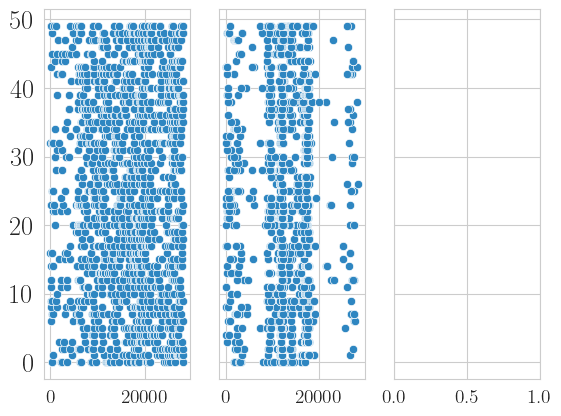

In [37]:
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
metis_permutation_path = "/home/cosimorulli/next_develop_seismic/seismic_private/_metis_8edf21a894a9745b.txt"
metis_permutation = np.loadtxt(metis_permutation_path)

rgb_permutation_path = "/home/cosimorulli/next_develop_seismic/seismic_private/_graph_bisection_6f13c60c0609ee4f.txt"
rgb_permutation = np.loadtxt(rgb_permutation_path)


fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, sharey=True)

xs = []
ys = []

for i , idx in enumerate(doc_ids):
    doc = document[idx]
    components = list(doc.keys())
    xs.extend(components)
    ys.extend([i] * len(components))
sns.scatterplot(x=xs, y=ys, ax=ax1)



xs_perm = []
ys_perm = []
for i , idx in enumerate(doc_ids):
    doc = document[idx]
    components_perm = [metis_permutation[x] for x in list(doc.keys())]
    xs_perm.extend(components_perm)
    ys_perm.extend([i] * len(components_perm))

xs_perm_rgb = []
ys_perm_rgb = []




sns.scatterplot(x=xs_perm, y=ys_perm, ax=ax2)

In [43]:
len(components_perm)

38

In [8]:
rgb_permutation_path = "/home/cosimorulli/next_develop_seismic/seismic_private/_graph_bisection_6f13c60c0609ee4f.txt"
rgb_permutation = np.loadtxt(rgb_permutation_path, dtype=np.int64)

In [9]:
from collections import Counter

delta_counter = Counter()

for doc in tqdm(document):
    converted_and_sorted = np.sort(np.array([rgb_permutation[x] for x in doc.keys()]))
    diffs = converted_and_sorted[1:] - converted_and_sorted[:-1]
    delta_counter.update(diffs)


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8841823/8841823 [06:47<00:00, 21712.64it/s]


In [10]:
xs, ys = zip(*delta_counter.most_common())

In [11]:
xs = np.array(list(xs))

In [13]:
ys = np.array(list(ys))

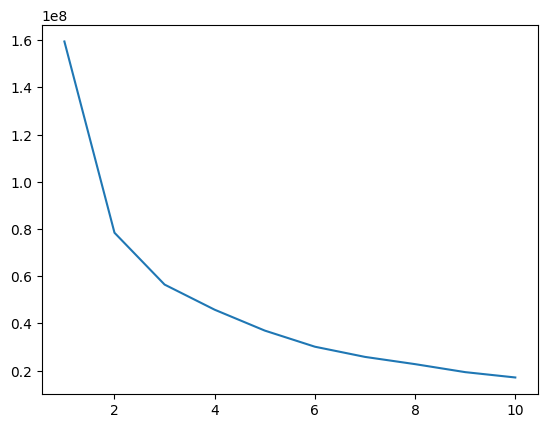

In [30]:
import matplotlib.pyplot as plt
lim = 10_000
plt.plot(xs[:10], ys[:10])

In [25]:
cmsum = np.cumsum(ys) 

rel_cmsum = cmsum / cmsum[-1]

In [28]:
rel_cmsum[:500]

array([0.15156693, 0.22610365, 0.27976442, 0.32329941, 0.35842846,
       0.38706671, 0.41160086, 0.43321945, 0.45161857, 0.46786652,
       0.48254896, 0.49614944, 0.5091659 , 0.52061557, 0.53101709,
       0.54058304, 0.54960273, 0.55796474, 0.56593344, 0.5734972 ,
       0.58071654, 0.5875256 , 0.59395687, 0.60014167, 0.60630041,
       0.61214811, 0.61780927, 0.62325046, 0.62845475, 0.63336565,
       0.63822825, 0.64276425, 0.64699665, 0.65109279, 0.65505979,
       0.65887467, 0.66267319, 0.66624709, 0.6697759 , 0.67325016,
       0.6767224 , 0.68011358, 0.68330601, 0.68649431, 0.68963106,
       0.69254058, 0.69537247, 0.69816388, 0.7009405 , 0.70366173,
       0.70633607, 0.70900793, 0.71161993, 0.7141549 , 0.71665009,
       0.7190868 , 0.72151178, 0.72386805, 0.72621967, 0.7284678 ,
       0.73058055, 0.73268854, 0.73474703, 0.7367901 , 0.73876271,
       0.74072177, 0.74263912, 0.7445101 , 0.74637658, 0.74822079,
       0.75005926, 0.75187367, 0.75361489, 0.75532538, 0.75697